# EDA 

clasificador de pruebas ECO Escritura

In [1]:
import pandas as pd
import warnings
warnings.filterwarnings("ignore")

df = pd.read_csv(r"C:\Users\Sistemas\Desktop\PFINAL\docs\nuevo_df.csv", encoding="utf-8-sig")

print("=== Info del DataFrame ===")
df.info()


=== Info del DataFrame ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1920 entries, 0 to 1919
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   id_uni      1920 non-null   object
 1   clean_text  1920 non-null   object
 2   Nivel_f     1920 non-null   object
dtypes: object(3)
memory usage: 45.1+ KB


In [2]:
print("\n=== Primeras filas ===")
print(df.head())


=== Primeras filas ===
    id_uni                                         clean_text     Nivel_f
0  train_0  otro aspecto que podemos tener en cuenta es la...  Medio bajo
1  train_1  En segundo lugar, el aprendizaje de lectura y ...  Medio alto
2  train_2  en segundo lugar, fomentando estas practicas d...  Medio bajo
3  train_3  En segundo lugar, la lectura y escritura es fu...  Medio bajo
4  train_4  La lectura y la escritura son importantes para...  Medio bajo


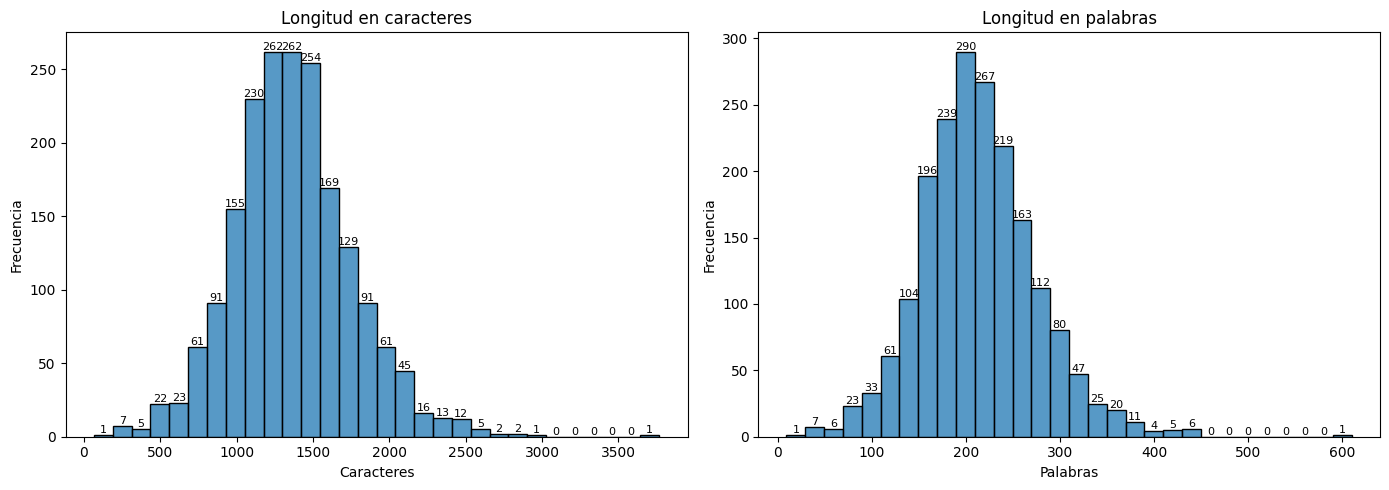

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

# Longitudes
df['char_count'] = df['clean_text'].str.len()
df['word_count'] = df['clean_text'].str.split().apply(len)

fig, axs = plt.subplots(1, 2, figsize=(14, 5))

# Histograma de caracteres
sns.histplot(df['char_count'], bins=30, ax=axs[0])
axs[0].set(title="Longitud en caracteres", xlabel="Caracteres", ylabel="Frecuencia")
for p in axs[0].patches:
    # p.get_height() es la frecuencia de cada bin
    axs[0].annotate(int(p.get_height()),
                    (p.get_x() + p.get_width() / 2, p.get_height()),
                    ha='center', va='bottom', fontsize=8)

# Histograma de palabras
sns.histplot(df['word_count'], bins=30, ax=axs[1])
axs[1].set(title="Longitud en palabras", xlabel="Palabras", ylabel="Frecuencia")
for p in axs[1].patches:
    axs[1].annotate(int(p.get_height()),
                    (p.get_x() + p.get_width() / 2, p.get_height()),
                    ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.show()



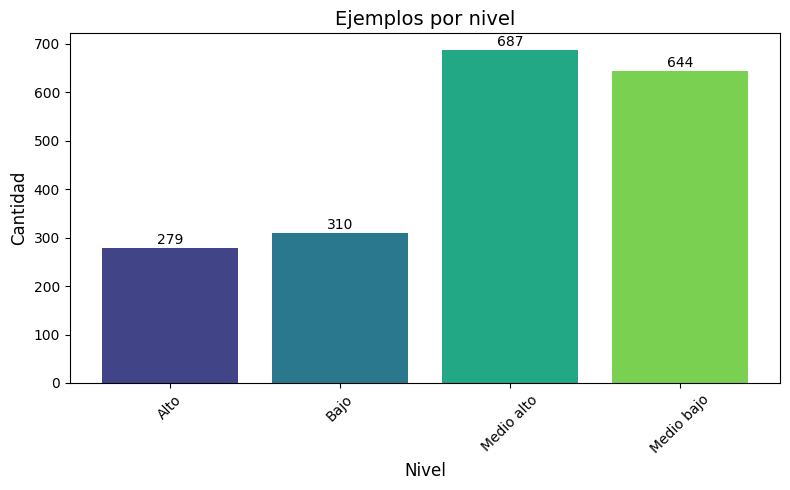

In [4]:
import numpy as np

# 1) Conteo ordenado por nivel
counts = df['Nivel_f'].value_counts().sort_index()
levels = counts.index
values = counts.values

# 2) Creamos un degradado de colores con viridis
colors = plt.cm.viridis(np.linspace(0.2, 0.8, len(levels)))

# 3) Dibujamos el barplot con color explícito
fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(levels, values, color=colors)

# 4) Etiquetas y títulos
ax.set_title("Ejemplos por nivel", fontsize=14)
ax.set_xlabel("Nivel", fontsize=12)
ax.set_ylabel("Cantidad", fontsize=12)
plt.xticks(rotation=45)

# 5) Numerar cada barra
for bar in bars:
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width() / 2,  # X en el centro de la barra
        height + 2,                         # un poco por encima
        f"{int(height)}",                   # texto
        ha='center', va='bottom', fontsize=10
    )

plt.tight_layout()
plt.show()


### Uso de STANZA para conteo de palabras por clase

2025-05-01 18:20:35 INFO: Checking for updates to resources.json in case models have been updated.  Note: this behavior can be turned off with download_method=None or download_method=DownloadMethod.REUSE_RESOURCES
2025-05-01 18:20:35 INFO: Downloaded file to C:\Users\Sistemas\stanza_resources\resources.json
2025-05-01 18:20:35 WARNING: Language es package default expects mwt, which has been added
2025-05-01 18:20:35 INFO: Loading these models for language: es (Spanish):
| Processor | Package  |
------------------------
| tokenize  | combined |
| mwt       | combined |

2025-05-01 18:20:35 INFO: Using device: cpu
2025-05-01 18:20:35 INFO: Loading: tokenize
2025-05-01 18:20:36 INFO: Loading: mwt
2025-05-01 18:20:36 INFO: Done loading processors!


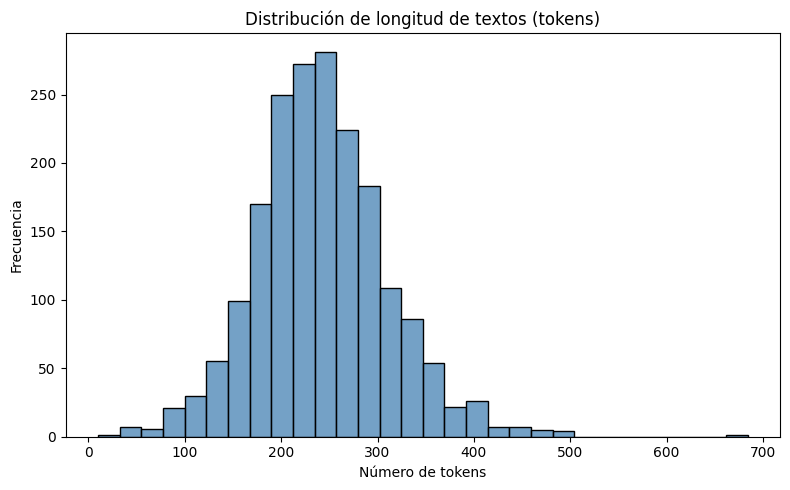

In [5]:
# ================================
# 2.X: Conteo de tokens y Top 10 palabras por clase usando Stanza + spaCy
# ================================
import stanza
import spacy
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

# --- 1) Configuración de Stanza y spaCy ---------------------------------------
# stanza.download('es')  # Descomenta sólo la primera vez
nlp_stanza = stanza.Pipeline(lang='es',
                             processors='tokenize',
                             use_gpu=False)       # o True si tu GPU está bien configurada

nlp_spacy = spacy.load('es_core_news_sm')          # Modelo sm basta para stopwords
stopwords_es = nlp_spacy.Defaults.stop_words

# --- 2) Función de conteo de tokens -------------------------------------------
def stanza_word_count(text: str) -> int:
    """Devuelve el número de tokens (Stanza) en un texto."""
    doc = nlp_stanza(text)
    # Cada sentencia es doc.sentences, cada sentence.tokens es lista de tokens
    return sum(len(sent.tokens) for sent in doc.sentences)

# --- 3) Añadir columna word_count al DataFrame --------------------------------
df['word_count'] = df['clean_text'].apply(stanza_word_count)

# --- 4) Histograma de longitudes de texto -------------------------------------
plt.figure(figsize=(8,5))
sns.histplot(df['word_count'], bins=30, kde=False, color='steelblue')
plt.title('Distribución de longitud de textos (tokens)')
plt.xlabel('Número de tokens')
plt.ylabel('Frecuencia')
plt.tight_layout()
plt.show()


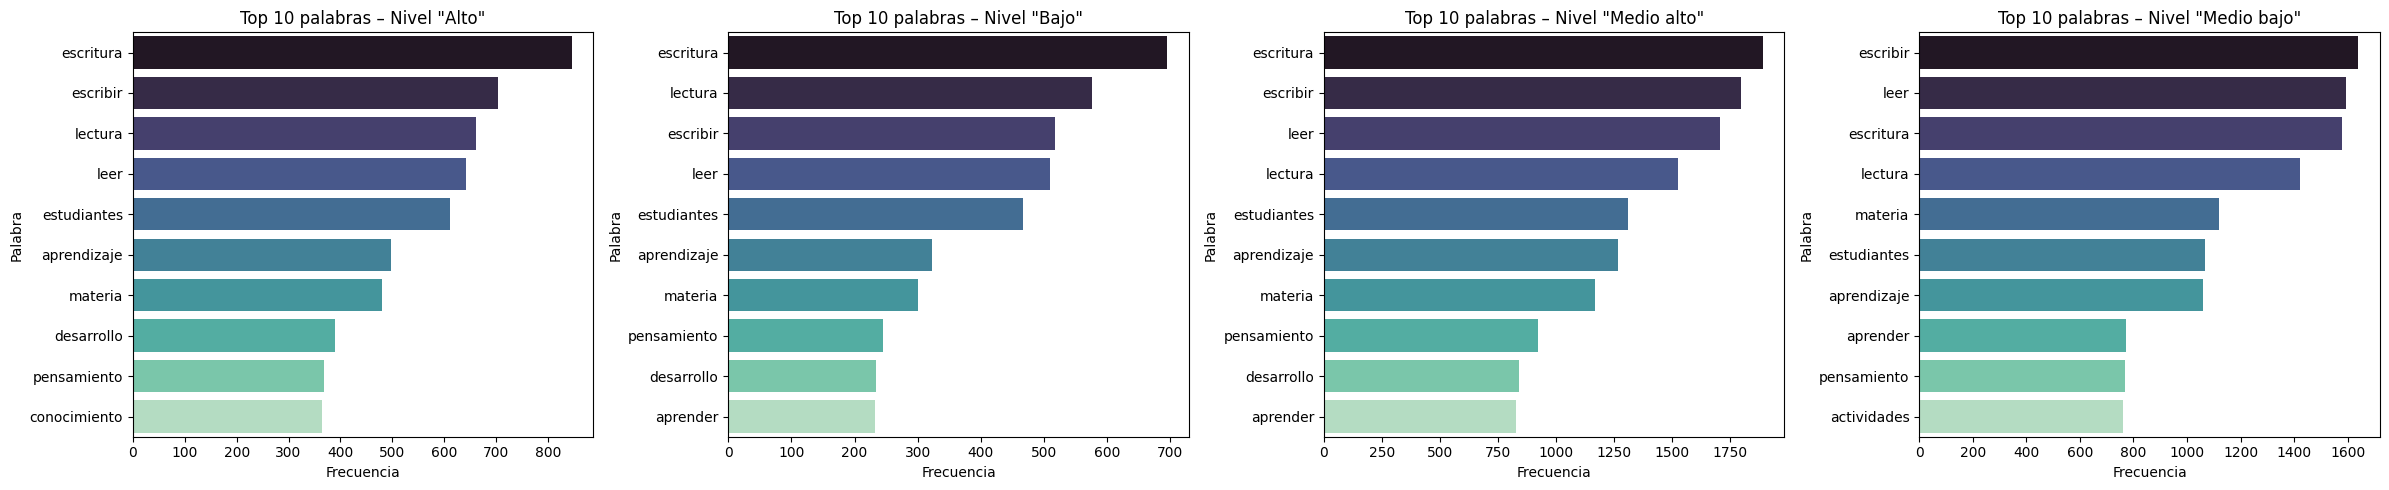

In [6]:
# ==========================
# Top-10 palabras por nivel en una sola fila
# ==========================
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

# Obtenemos la lista de niveles (asegura orden consistente)
niveles = sorted(df['Nivel_f'].unique())

# Preparamos la figura con 4 subplots en fila
fig, axes = plt.subplots(1, len(niveles), figsize=(24, 5), sharex=False, sharey=False)

for i, nivel in enumerate(niveles):
    grupo = df[df['Nivel_f'] == nivel]
    tokens_all = []
    for txt in grupo['clean_text']:
        doc = nlp_stanza(txt)
        for sent in doc.sentences:
            for tok in sent.tokens:
                w = tok.text.lower()
                if w.isalpha() and w not in stopwords_es:
                    tokens_all.append(w)
    cnt = Counter(tokens_all)
    top10 = cnt.most_common(10)
    if top10:
        palabras, frecuencias = zip(*top10)
    else:
        palabras, frecuencias = [], []

    ax = axes[i]
    sns.barplot(
        x=list(frecuencias),
        y=list(palabras),
        palette='mako',
        ax=ax
    )
    ax.set_title(f'Top 10 palabras – Nivel "{nivel}"')
    ax.set_xlabel('Frecuencia')
    ax.set_ylabel('Palabra')

plt.tight_layout()
plt.show()
